<div style="text-align: center;">
  <img src="aerofit-logo.png" alt="Description" style="width: 40%; height: auto;">
</div>


<h1 style="text-align: center";>
    AEROFIT BUSINESS CASE STUDY
</h1>
<h3 style="text-align:center">
    BY: Atharva Nitin Deshpande
</h3>
<div style="text-align:center">
    Data Science and Machine Learning Program 2024, Scaler Academy, India
</div>

# Introduction

**About Aerofit**

Aerofit is a leading brand in the field of fitness equipment. Aerofit provides a product range including machines such as treadmills, exercise bikes, gym equipment, and fitness accessories to cater to the needs of all categories of people.

**Business Problem**

The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the company, to provide a better recommendation of the treadmills to the new customers. Their product portfolio for the treadmills is as follows:

* The KP281 is an entry-level treadmill that sells for $1,500.

* The KP481 is for mid-level runners that sell for $1,750.

* The KP781 treadmill is having advanced features that sell for $2,500.

The following document portrays this case study, along with actionable Insights and recommendations for customer segmentation, for each product (treadmill).

# Non-Graphical Analysis

**Importing the necessory libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown,display
import warnings
warnings.filterwarnings('ignore')

**Importing the dataset**

The company collected the data on individuals who purchased a treadmill from the AeroFit stores during the prior three months.

Let us examine the first 5 rows of the dataset.

In [2]:
df = pd.read_csv('aerofit_treadmill.csv')
df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


As we can see, the dataset has the following features:

**Product Purchased**:	KP281, KP481, or KP781

**Age**: In years

**Gender**: Male/Female

**Education**: In years

**MaritalStatus**: Single or partnered

**Usage**: The average number of times the customer plans to use the treadmill each week.

**Income**: Annual income (in $)

**Fitness**: Self-rated fitness on a 1-to-5 scale, where 1 is the poor shape and 5 is the excellent shape.

**Miles**: The average number of miles the customer expects to walk/run each week


Let us check the shape of dataset.

In [3]:
df.shape

(180, 9)

The dataset has 180 rows and 9 columns (i.e. features).

Let us further explore the dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


In [5]:
np.any(df.duplicated())

False

In [6]:
df.isna().sum()

Product          0
Age              0
Gender           0
Education        0
MaritalStatus    0
Usage            0
Fitness          0
Income           0
Miles            0
dtype: int64

As we can see, for all the columns, the number of non-null entries is equal to the number of rows i.e. 180, which means the dataset does not have any missing values. Furthermore, the dataset also does not have any duplicate rows.

Let us check the unique values for each feature.

In [7]:
for column in df:
    display(Markdown(f"Column: {column}"))
    print(f"Data Type: {df[column].dtype}")
    print('Unique Values:')
    print(list(df[column].unique()))
    print('\n')

Column: Product

Data Type: object
Unique Values:
['KP281', 'KP481', 'KP781']




Column: Age

Data Type: int64
Unique Values:
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 46, 47, 50, 45, 48, 42]




Column: Gender

...

Data Type: int64
Unique Values:
[4, 3, 2, 1, 5]




Column: Income

Data Type: int64
Unique Values:
[29562, 31836, 30699, 32973, 35247, 37521, 36384, 38658, 40932, 34110, 39795, 42069, 44343, 45480, 46617, 48891, 53439, 43206, 52302, 51165, 50028, 54576, 68220, 55713, 60261, 67083, 56850, 59124, 61398, 57987, 64809, 47754, 65220, 62535, 48658, 54781, 48556, 58516, 53536, 61006, 57271, 52291, 49801, 62251, 64741, 70966, 75946, 74701, 69721, 83416, 88396, 90886, 92131, 77191, 52290, 85906, 103336, 99601, 89641, 95866, 104581, 95508]




Column: Miles

Data Type: int64
Unique Values:
[112, 75, 66, 85, 47, 141, 103, 94, 113, 38, 188, 56, 132, 169, 64, 53, 106, 95, 212, 42, 127, 74, 170, 21, 120, 200, 140, 100, 80, 160, 180, 240, 150, 300, 280, 260, 360]




The ```fitness``` column represents ratings from 1 to 5, which have an order (1 < 2 < 3 < 4 < 5). While they are represented as integers, they are not numerical values meant for arithmetic operations. Hence, converting this column to a categorical type, will make it easier to analyze and visualize.

In [8]:
df['Fitness'] = pd.Categorical(df['Fitness'], categories=[1,2,3,4,5], ordered=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Product        180 non-null    object  
 1   Age            180 non-null    int64   
 2   Gender         180 non-null    object  
 3   Education      180 non-null    int64   
 4   MaritalStatus  180 non-null    object  
 5   Usage          180 non-null    int64   
 6   Fitness        180 non-null    category
 7   Income         180 non-null    int64   
 8   Miles          180 non-null    int64   
dtypes: category(1), int64(5), object(3)
memory usage: 11.8+ KB


For ease of analysis, the numerical and categorical features are separated into two dataframes.

In [10]:
df_num = df.select_dtypes(include=['int64','float64'])
df_cat = df.select_dtypes(exclude=['int64','float64'])

In [11]:
df_num.head()

,Age,Education,Usage,Income,Miles
0,18,14,3,29562,112
1,19,15,2,31836,75
2,19,14,4,30699,66
3,19,12,3,32973,85
4,20,13,4,35247,47


In [12]:
df_cat.head()

,Product,Gender,MaritalStatus,Fitness
0,KP281,Male,Single,4
1,KP281,Male,Single,3
2,KP281,Female,Partnered,3
3,KP281,Male,Single,3
4,KP281,Male,Partnered,2


In [13]:
df_num_desc = np.round(df_num.describe().T,1)
num_units = ['years','years','times a week','Dollars','per week','Dollars','']
for column,unit in zip(df_num_desc.index,num_units):
    display(Markdown(f"The average <b>{column}</b> is <u>{df_num_desc['mean'][column]} {unit}</u>, with a minimum of <u>{df_num_desc['min'][column]} {unit}</u> and a maximum of <u>{df_num_desc['max'][column]} {unit}</u>."))

The average <b>Age</b> is <u>28.8 years</u>, with a minimum of <u>18.0 years</u> and a maximum of <u>50.0 years</u>.

The average <b>Education</b> is <u>15.6 years</u>, with a minimum of <u>12.0 years</u> and a maximum of <u>21.0 years</u>.

The average <b>Usage</b> is <u>3.5 times a week</u>, with a minimum of <u>2.0 times a week</u> and a maximum of <u>7.0 times a week</u>.

The average <b>Income</b> is <u>53719.6 Dollars</u>, with a minimum of <u>29562.0 Dollars</u> and a maximum of <u>104581.0 Dollars</u>.

The average <b>Miles</b> is <u>103.2 per week</u>, with a minimum of <u>21.0 per week</u> and a maximum of <u>360.0 per week</u>.

In [14]:
df_cat_desc = df_cat.describe().T
for column in df_cat_desc.index:
    display(Markdown(f"The most frequently occuring <b>{column}</b> is <u>{df_cat_desc['top'][column]}</u>, with a count of {df_cat_desc['freq'][column]}."))

The most frequently occuring <b>Product</b> is <u>KP281</u>, with a count of 80.

The most frequently occuring <b>Gender</b> is <u>Male</u>, with a count of 104.

The most frequently occuring <b>MaritalStatus</b> is <u>Partnered</u>, with a count of 107.

The most frequently occuring <b>Fitness</b> is <u>3</u>, with a count of 97.

# Univariate Analysis

## Numerical Features

In [15]:
column_colors = ['red','orange','yellow','green','blue','indigo']

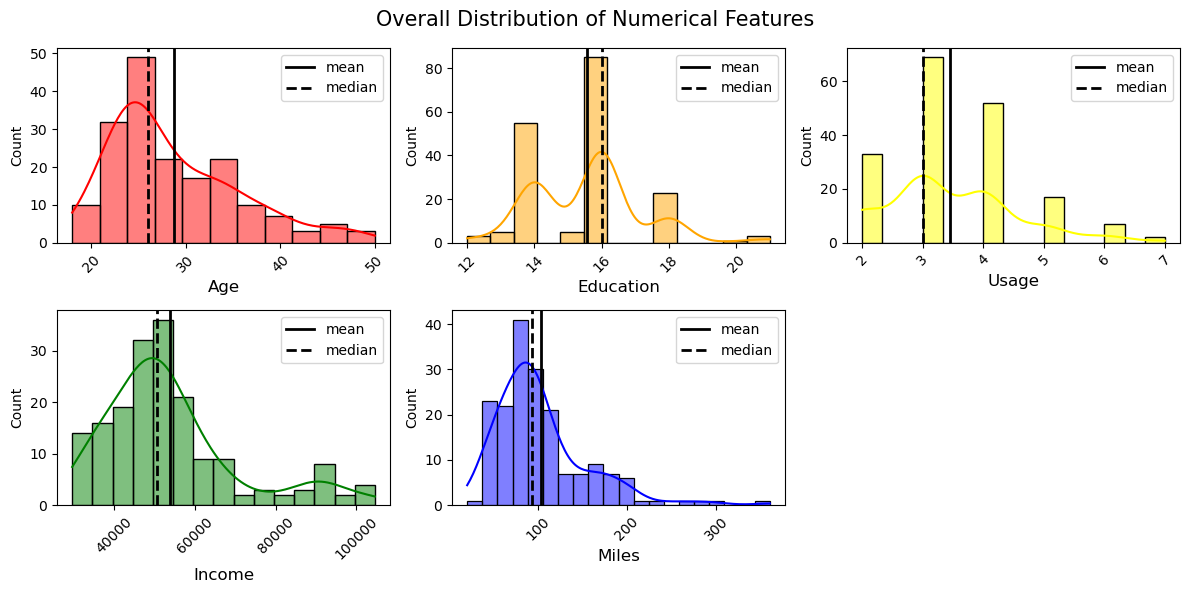

In [16]:
plt.figure(figsize=(12,6)).suptitle('Overall Distribution of Numerical Features', fontsize=15)

for i, column, color in zip(range(len(df_num.columns)), df_num, column_colors):
    plt.subplot(2,int(np.ceil(len(df_num.columns)/2)),i+1)
    sns.histplot(data=df_num, 
                 x=column, 
                 kde=True,
                 color=color)
    plt.xticks(rotation=45)
    plt.xlabel(column, fontsize=12)
    plt.axvline(np.mean(df[column]),
                linestyle='-', 
                linewidth=2,
                color='black', 
                label='mean')
    plt.axvline(np.median(df[column]),
                linestyle='--', 
                linewidth=2,
                color='black', 
                label='median')
    plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [17]:
np.round(df.groupby('Product')[list(df_num.columns)].mean().add_prefix('Mean_'),1)

,Mean_Age,Mean_Education,Mean_Usage,Mean_Income,Mean_Miles
Product,,,,,
KP281,28.6,15.0,3.1,46418.0,82.8
KP481,28.9,15.1,3.1,48973.6,87.9
KP781,29.1,17.3,4.8,75441.6,166.9


In [18]:
np.round(df.groupby('Product')[list(df_num.columns)].median().add_prefix('Median_'),1)

,Median_Age,Median_Education,Median_Usage,Median_Income,Median_Miles
Product,,,,,
KP281,26.0,16.0,3.0,46617.0,85.0
KP481,26.0,16.0,3.0,49459.5,85.0
KP781,27.0,18.0,5.0,76568.5,160.0


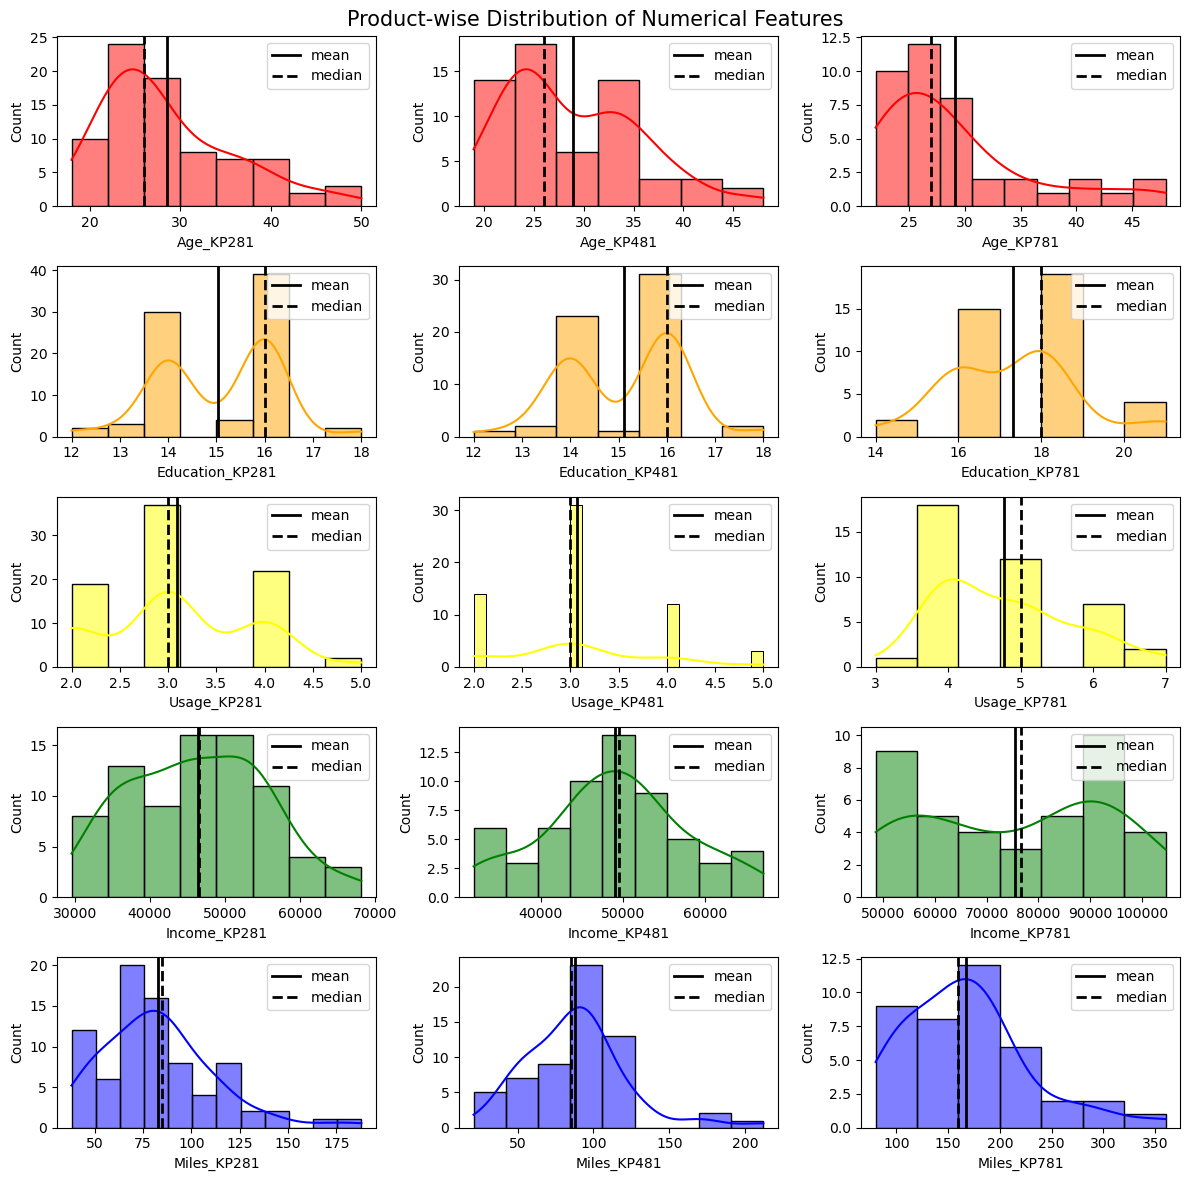

In [19]:
plt.figure(figsize=(12,12)).suptitle('Product-wise Distribution of Numerical Features', fontsize=15)
i=1
while i <= len(df_num.columns) * len(df['Product'].unique()):
    for column,color in zip(df_num,column_colors):
        for product in df['Product'].unique():
            plt.subplot(len(df_num.columns), len(df['Product'].unique()), i)
            # Histogram
            sns.histplot(data=df[df['Product']==product], 
                         x=column,
                         kde=True, 
                         color=color)
            # Mean
            plt.axvline(np.mean(df[df['Product']==product][column]),
                        linestyle='-', 
                        linewidth=2,
                        color='black',
                        label='mean')
            # Median
            plt.axvline(np.median(df[df['Product']==product][column]), 
                        linestyle='--',
                        linewidth=2,
                        color='black',
                        label='median')
            plt.xlabel(column+'_'+product)
            plt.legend(loc='upper right')
            i += 1
plt.tight_layout()
plt.show()

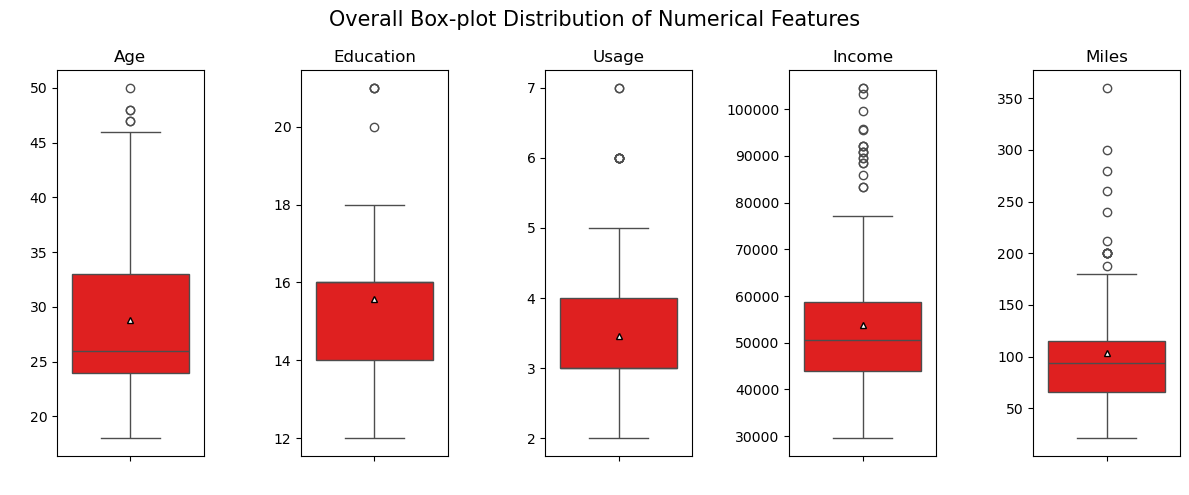

In [20]:
plt.figure(figsize=(12,5)).suptitle('Overall Box-plot Distribution of Numerical Features', fontsize=15)

for i,column in zip(range(len(df_num.columns)),df_num):
    plt.subplot(1,len(df_num.columns),i+1)
    plt.title(column, fontsize=12)
    sns.boxplot(data=df, 
                y=column, 
                color='red',                
                showmeans=True,
                meanprops={"marker":"^",
                           "markerfacecolor":"white", 
                           "markeredgecolor":"black",
                           "markersize":"5"})
    plt.xticks(rotation=45)
    plt.xlabel(' ')
    plt.ylabel(' ')

plt.tight_layout()
plt.show()

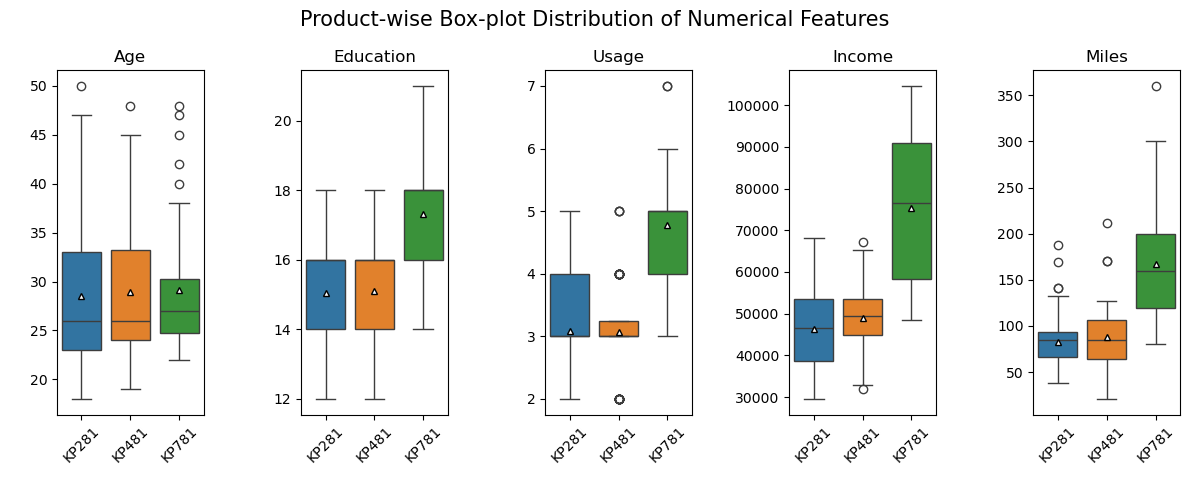

In [21]:
plt.figure(figsize=(12,5)).suptitle('Product-wise Box-plot Distribution of Numerical Features', fontsize=15)

for i,column in zip(range(len(df_num.columns)),df_num):
    plt.subplot(1,len(df_num.columns),i+1)
    plt.title(column, fontsize=12)
    sns.boxplot(data=df, 
                x='Product', 
                y=column, 
                hue='Product',
                showmeans=True,
                meanprops={"marker":"^",
                           "markerfacecolor":"white", 
                           "markeredgecolor":"black",
                           "markersize":5})
    plt.xticks(rotation=45)
    plt.xlabel(' ')
    plt.ylabel(' ')

plt.tight_layout()
plt.show()

## Categorical Features

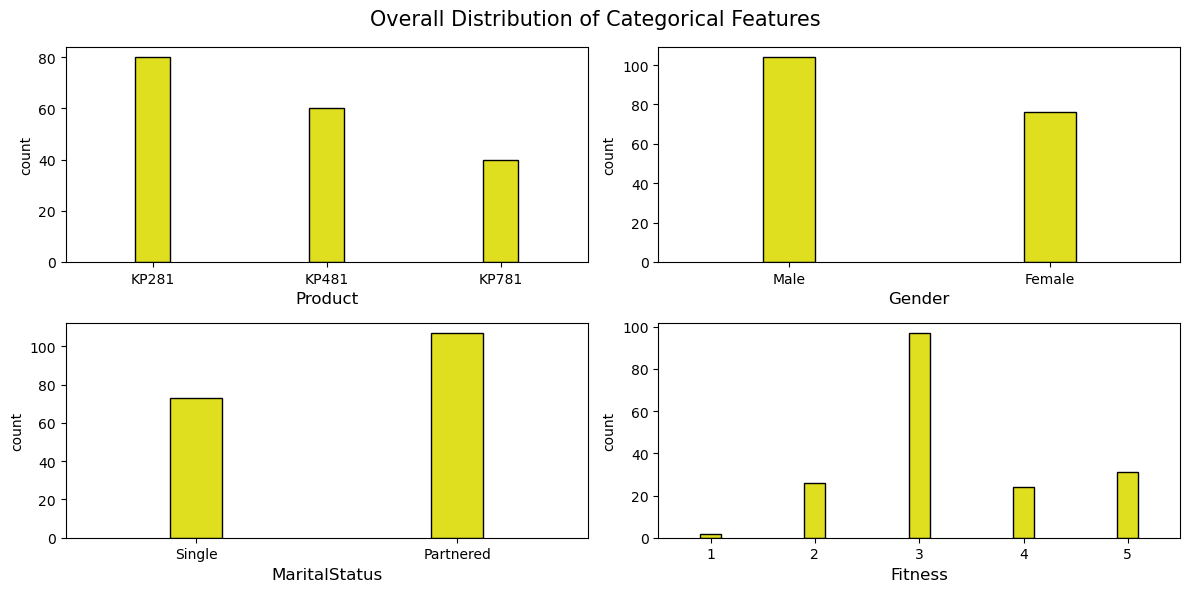

In [22]:
plt.figure(figsize=(12,6)).suptitle('Overall Distribution of Categorical Features', fontsize=15)

for i, column in zip(range(len(df_cat.columns)),df_cat):
    plt.subplot(2,int(np.ceil(len(df_cat.columns)/2)),i+1)
    sns.countplot(data=df_cat, 
                  x=column, 
                  color='yellow', 
                  width=0.2, 
                  edgecolor='black')
    plt.xlabel(column, fontsize=12)

plt.tight_layout()
plt.show()

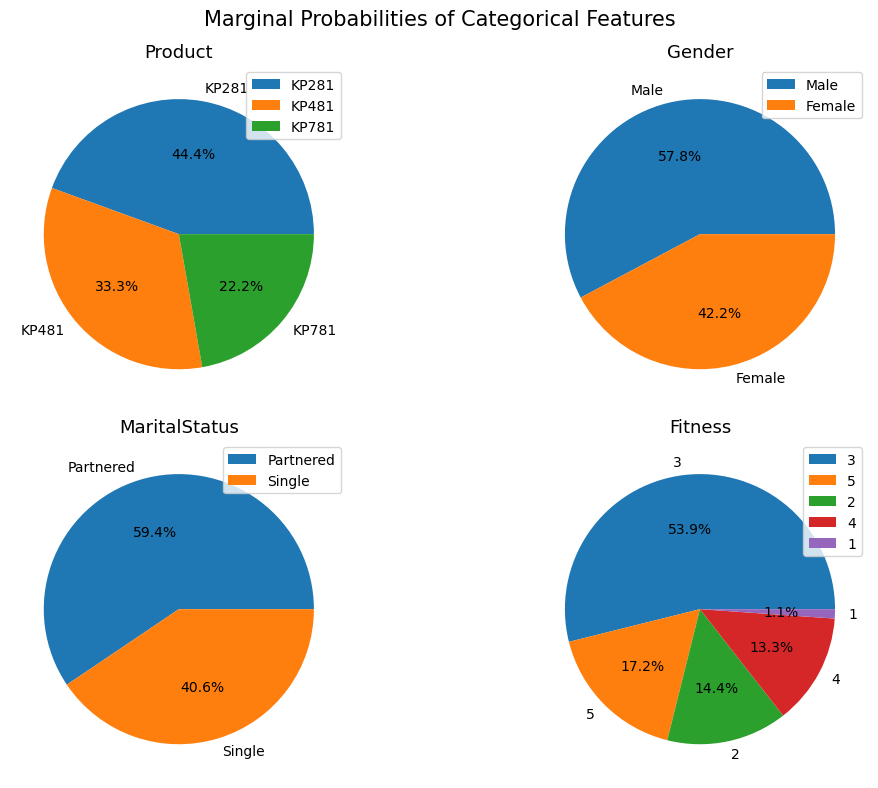

In [23]:
plt.figure(figsize=(12,8)).suptitle('Marginal Probabilities of Categorical Features', fontsize=15)

for i, column in zip(range(len(df_cat.columns)),df_cat):
    plt.subplot(2,int(np.ceil(len(df_cat.columns)/2)),i+1)
    plt.title(f'{column}', fontsize=13)
    plt.pie(x=df_cat[column].value_counts(), 
            labels=df_cat[column].value_counts().index, 
            autopct='%.1f%%')
    plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

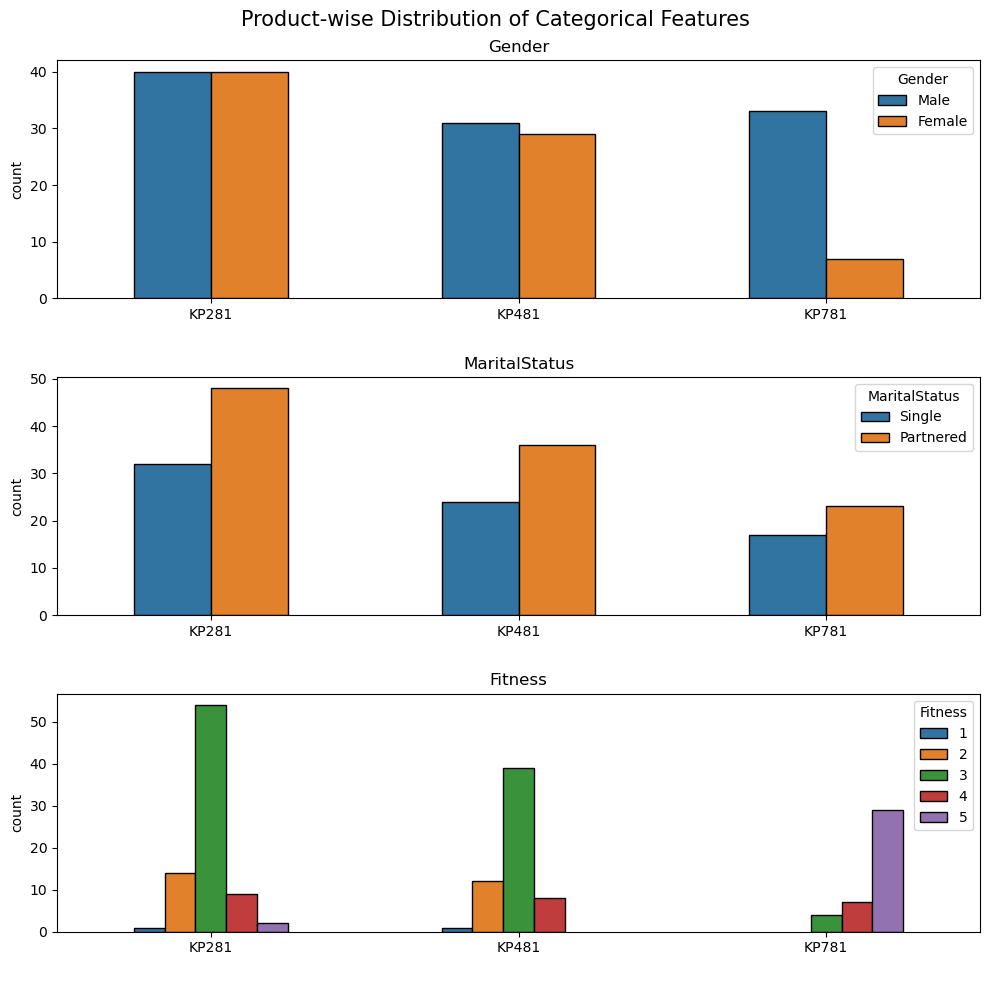

In [24]:
plt.figure(figsize=(10,10)).suptitle('Product-wise Distribution of Categorical Features', fontsize=15)

for i,column in zip(range(len(df_cat.drop('Product',axis=1).columns)),df_cat.drop('Product',axis=1)):
    plt.subplot(len(df_cat.drop('Product',axis=1).columns),1,i+1)
    sns.countplot(data=df_cat, 
                  x='Product', 
                  hue=column,
                  width=0.5,
                  edgecolor='black')
    plt.title(column, fontsize=12)
    plt.xlabel(' ')

plt.tight_layout()
plt.show()

# Multivariate Analysis

## Conditional Probabilities

In [25]:
for column in df_cat:
    if column != 'Product':
        x = np.round(pd.crosstab(df['Product'],df[column],normalize='columns'),3)
        x_html = x.to_html()
        display(Markdown(f"<h2>{column}</h2>"))
        display(Markdown(x_html))
        if x.columns.name == 'Gender':
            for product in x.index:
                for gender in x:
                    display(Markdown(f"Approximately {np.round(x[gender][product]*100,1)}% of the {gender} customers prefer to buy a {product} treadmill model."))
                print('-----------------------------------------------------------------------------------')
        elif x.columns.name == 'MaritalStatus':
            for product in x.index:
                for status in x:
                    display(Markdown(f"Approximately {np.round(x[status][product]*100,1)}% of the {status} customers prefer to buy a {product} treadmill model."))
                print('-----------------------------------------------------------------------------------')
        elif x.columns.name == 'Fitness':
            for product in x.index:
                for rating in x:
                    display(Markdown(f"Approximately {np.round(x[rating][product]*100,1)}% of the customers with a Fitness rating of {rating} prefer to buy a {product} treadmill model."))
                print('-----------------------------------------------------------------------------------')
        print('\n')

<h2>Gender</h2>

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th>Gender</th>
      <th>Female</th>
      <th>Male</th>
    </tr>
    <tr>
      <th>Product</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>KP281</th>
      <td>0.526</td>
      <td>0.385</td>
    </tr>
    <tr>
      <th>KP481</th>
      <td>0.382</td>
      <td>0.298</td>
    </tr>
    <tr>
      <th>KP781</th>
      <td>0.092</td>
      <td>0.317</td>
    </tr>
  </tbody>
</table>

Approximately 52.6% of the Female customers prefer to buy a KP281 treadmill model.

Approximately 38.5% of the Male customers prefer to buy a KP281 treadmill model.

-----------------------------------------------------------------------------------


...

Approximately 0.0% of the customers with a Fitness rating of 2 prefer to buy a KP781 treadmill model.

Approximately 4.1% of the customers with a Fitness rating of 3 prefer to buy a KP781 treadmill model.

Approximately 29.2% of the customers with a Fitness rating of 4 prefer to buy a KP781 treadmill model.

Approximately 93.5% of the customers with a Fitness rating of 5 prefer to buy a KP781 treadmill model.

-----------------------------------------------------------------------------------




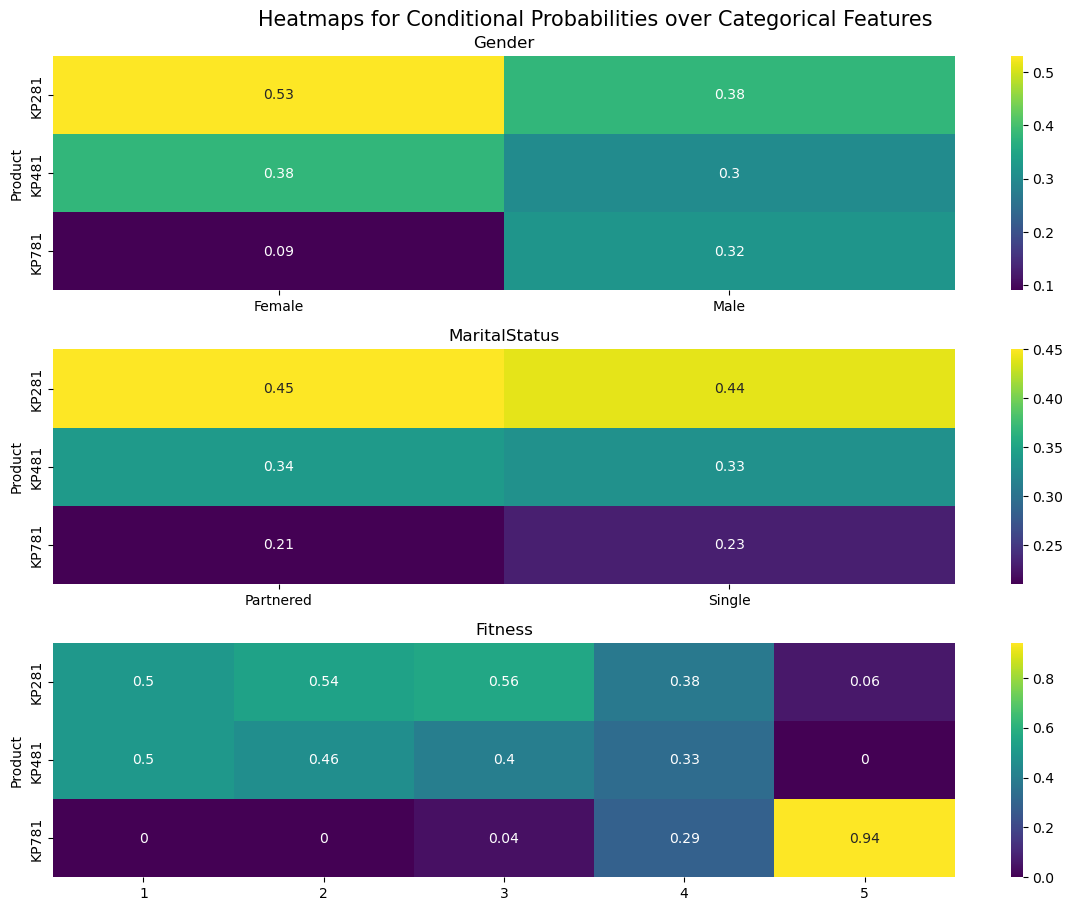

In [26]:
plt.figure(figsize=(12,12)).suptitle('Heatmaps for Conditional Probabilities over Categorical Features', fontsize=15)
df_cat_1 = df_cat.drop('Product',axis=1)
for i, column in zip(range(3),df_cat_1):
    if column != 'Product':
        x = np.round(pd.crosstab(df['Product'],df[column],normalize='columns'),2)
        plt.subplot(4,1,i+1)
        plt.title(column, fontsize=12)
        sns.heatmap(x, 
                    annot=True, 
                    cmap='viridis')
        plt.xlabel('')
        
plt.tight_layout()

## Correlation Analysis

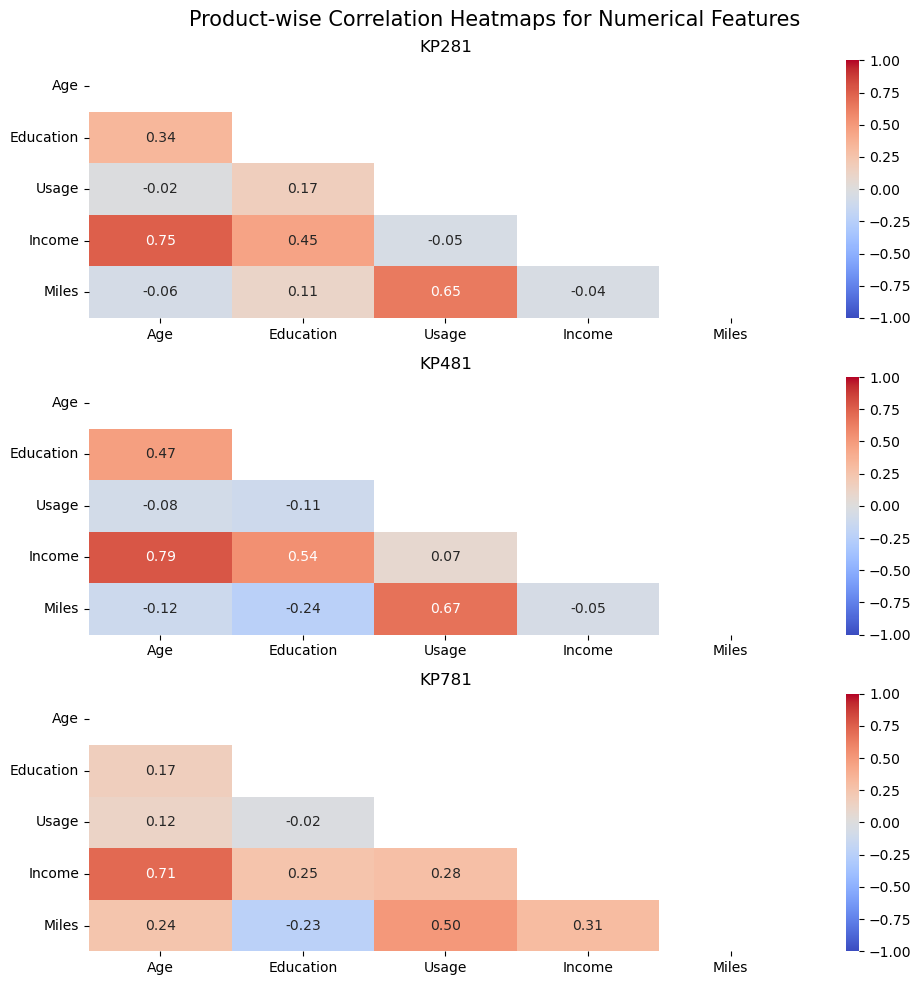

In [27]:
plt.figure(figsize=(10,10)).suptitle('Product-wise Correlation Heatmaps for Numerical Features', fontsize=15)
for i, product in zip(range(3), df['Product'].unique()):
    plt.subplot(3,1,i+1)
    plt.title(product)
    sns.heatmap(df[df['Product']==product].corr(numeric_only=True),
                vmin=-1.00,
                vmax=1.00,
                annot=True, 
                fmt='.2f', 
                cmap='coolwarm',
                mask=((np.triu(df.corr(numeric_only=True)))))
plt.tight_layout()

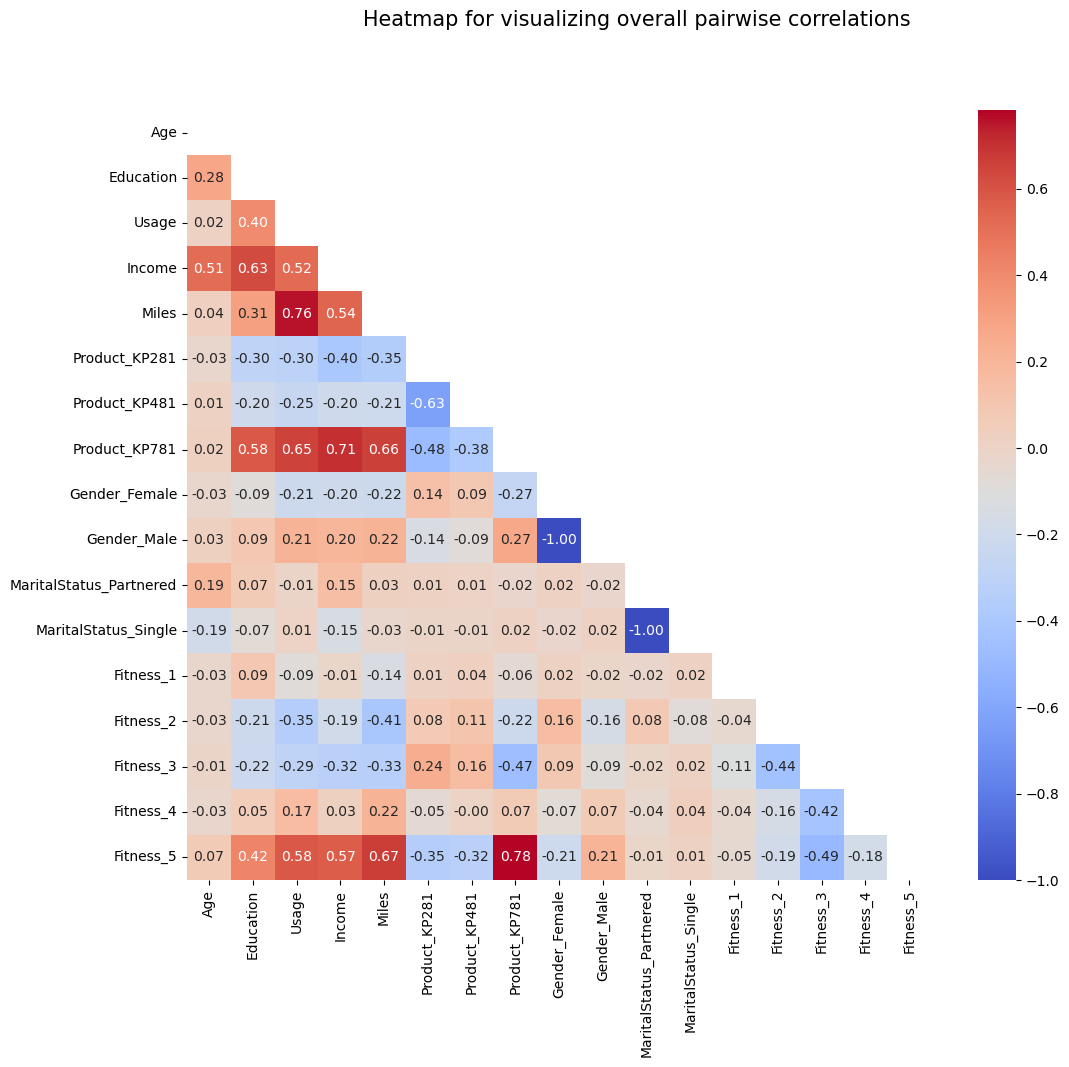

In [28]:
df_one_hot = pd.concat([df_num, pd.get_dummies(df_cat, dtype='int')], axis=1)

plt.figure(figsize=(12,10)).suptitle('Heatmap for visualizing overall pairwise correlations', fontsize=15)
sns.heatmap(df_one_hot.corr(), annot=True, mask=(np.triu(df_one_hot.corr())), fmt='.2f', cmap='coolwarm')
plt.show()

<Figure size 1200x1200 with 0 Axes>

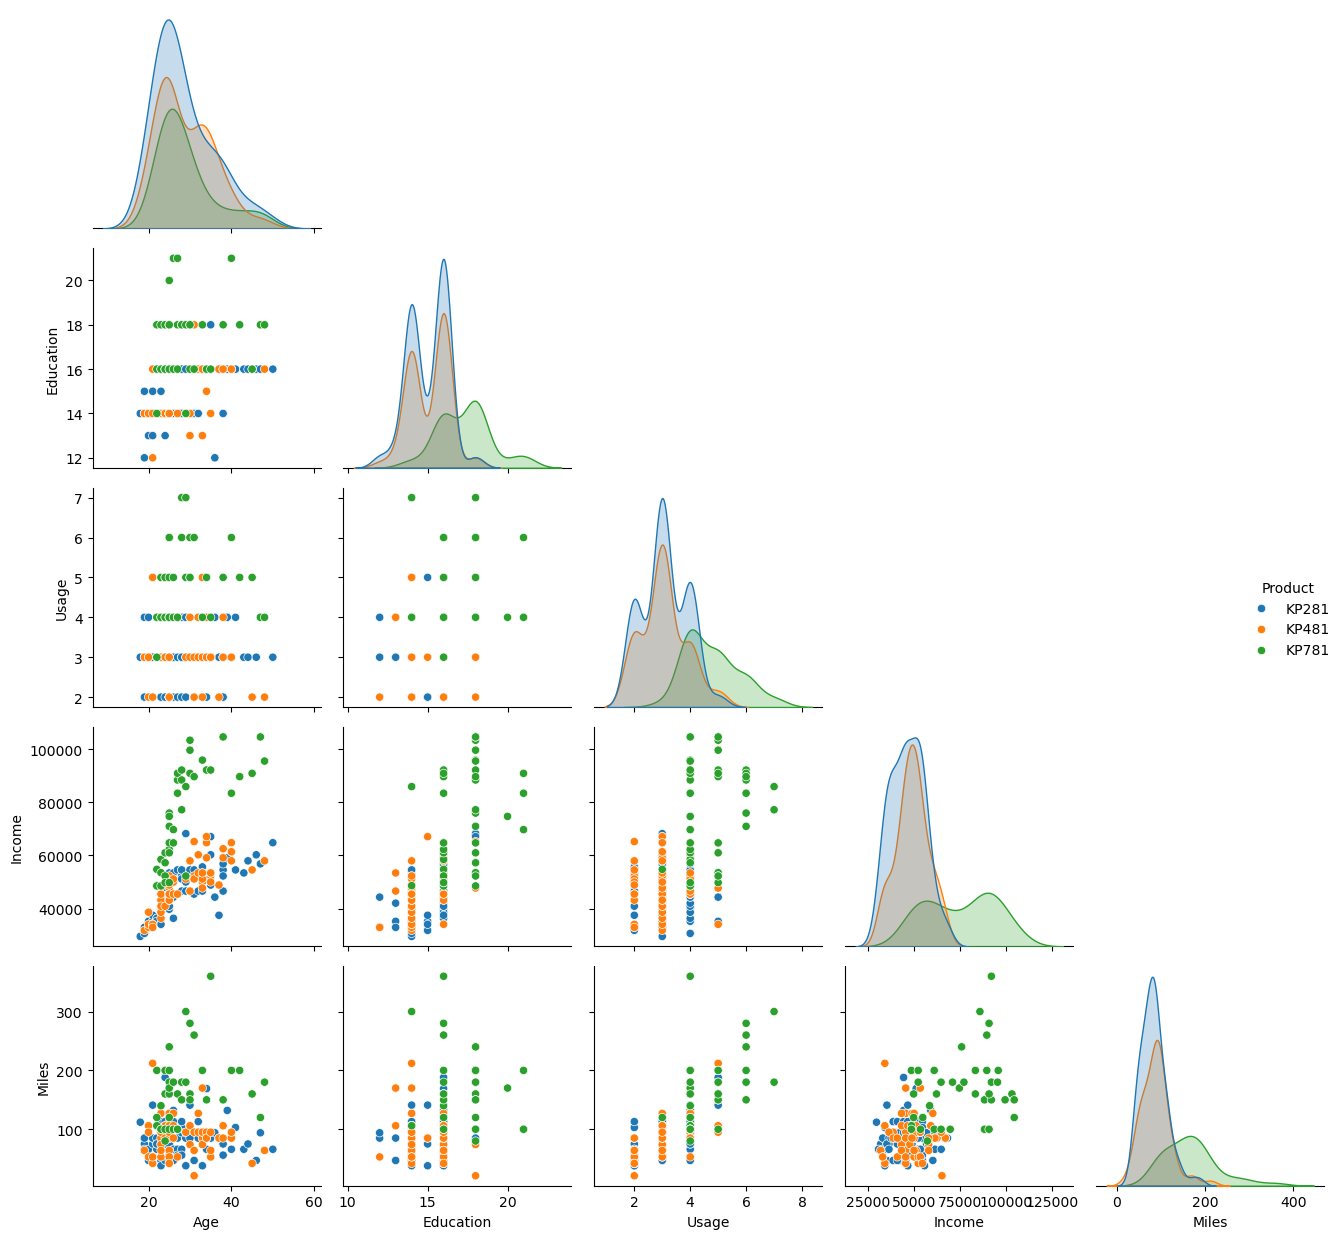

In [29]:
plt.figure(figsize=(12,12)).suptitle('Pairwise Numerical Feature Distributions and Relationships', fontsize=15)
sns.pairplot(df, hue='Product', corner=True)
plt.tight_layout()
plt.show()

# Conclusion

## General Insights

* Customers' age ranges between 18 to 50 years. There is a scope for manufacturing treadmills tailored to people with age of 50+ years, exclusively designed for walking.
* Income ranges from 29k to 104k dollars per annum.
* KP281 is the top-selling model.
* Overall, males buyers have a higher proportion (57.8%) than female buyers (42.2%).
* Overall, partnered buyers have a higher proportion (59.4%) than single buyers (40.6%), which indicates an increased consciousness to become fit due to accountability from the partner.
* Overall, buyers tend to believe to have a fitness rating of 3.
* Overall, income is positively correlated to age, education, usage per week and hence, miles per week.

## Customer Segments

<h4>
    <u>KP281</u>
</h4>

This entry-level treadmill model is the top-selling model by Aerofit, with a share of 44.4% of the total sales.
* Price: $1,500/-

* Average age of buyers is 28 years, while median age is 26 years. Typical age range is between 23 and 33 years.
* Overall, his model is preferred by both the genders equally. However, when we look at customers separately by gender, a higher proportion of female customers prefer this model compared to male customers.
* Education ranges from 14 to 16 years, for 50% of the buyers of this model.
* Average income of KP281 buyers is approximately 46k dollars, with a typical range between 40k to 53k dollars.
* Overall, partnered customers have a higher proportion in the sales of this model than single customers. However, a single/partnered customer is almost equally likely to buy this model.
* Customers with Fitness ratings 1/2/3/4 are most likely to buy KP281 model, with rating-3 customers being highest, indicating beginners to intermediate-level.
* On average, customers intend to use this treadmill 3 times a week, with a typical target of walking/running approximately 70 to 90 miles per week.

<h4>
    <u>KP481</u>
</h4>

This is an intermediate-level treadmill, with a 33.3% share in overall sales.
* Price: $1,750/-

* Average age of buyers is almost 29 years, while median age is 26 years. Typical age range is between 24 and 33 years.
* This model is also preferred by both the genders equally.
* Education ranges from 14 to 16 years, for 50% of the buyers of this model.
* Average income of KP481 buyers is approximately 49k dollars, with a typical range between 45k to 53k dollars.
* Overall, partnered customers have a higher proportion in the sales of this model than single customers. However, a single/partnered customer is almost equally likely to buy this model.
* Customers with Fitness ratings 1/2/3/4 are most likely to buy KP481 model, with rating-1 customers being highest, indicating beginners to intermediate-level.
* On average, customers intend to use this treadmill 3 times a week, with a typical target of walking/running approximately 70 to 110 miles per week.

<h4>
    <u>KP781</u>
</h4>

This treadmill has advanced features and is specially designed for experienced users.
* Price: $ 2,500/-

* Average age of buyers is 29 years, while median age is 27 years. Typical age range is between 25 and 30 years.
* This model is predominantly preferred by male buyers, with very few female buyers.
* Education ranges from 16 to 18 years, for 50% of the buyers of this model. Also, there is strong positive correlation between education and income, resulting into higher income and hence, better affordability towards an advanced model.
* Average income of KP781 buyers is approximately 75k dollars, with a typical range between 58k to 90k dollars. This model is preferred by customers of a significantly higher income bracket, indicating better affordability.
* Overall, partnered customers have a higher proportion in the sales of this model than single customers. However, a single/partnered customer is almost equally likely to buy this model.
* This model is predominantly preferred by customers with Fitness ratings of 4 or 5, with rating-5 customers being highest.
* On average, customers intend to use this treadmill almost 5 times a week, with a typical target of walking/running approximately 120 to 200 miles per week, indicating significantly higher goals, aligning with a higher fitness rating.

<Axes: xlabel='Product', ylabel='MaritalStatus-Gender'>

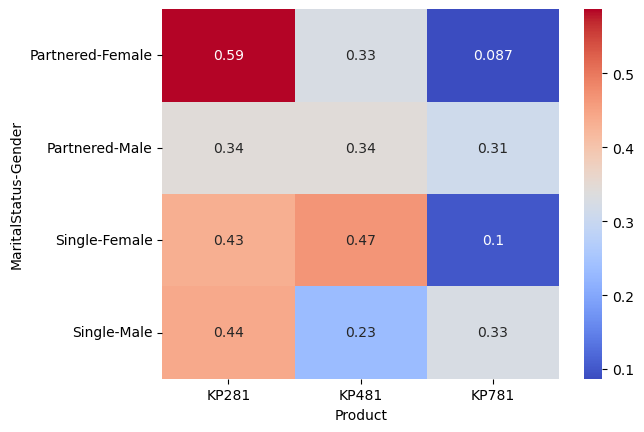

In [56]:
sns.heatmap(np.round(pd.crosstab(index=[df['MaritalStatus'],df['Gender']], columns=df['Product'],normalize='index'),3), annot=True, cmap='coolwarm')

In [49]:
df['MaritalStatus'].value_counts()

MaritalStatus
Partnered    107
Single        73
Name: count, dtype: int64